In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from data_loader import load_data

df = load_data("../Mental-Health-ml-project/data/mental_health_dataset.csv")
df.head()

,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours
0,1,36,Non-binary,Sales,Canada,No,Medium,Yes,Medium,7.1,46,5
1,2,34,Female,Education,UK,Yes,NaN,No,Low,7.5,47,8
2,3,65,Non-binary,Sales,USA,Yes,High,No,Low,8.4,58,10
3,4,34,Male,Other,Australia,No,Low,No,Medium,9.8,30,2
4,5,22,Female,Healthcare,Canada,Yes,Low,No,Medium,4.9,62,5


In [21]:
df.shape
df.columns
df.info()
df.isnull().sum()
df["Mental_Health_Condition"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  1000 non-null   int64  
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   Occupation               1000 non-null   object 
 4   Country                  1000 non-null   object 
 5   Mental_Health_Condition  1000 non-null   object 
 6   Severity                 499 non-null    object 
 7   Consultation_History     1000 non-null   object 
 8   Stress_Level             1000 non-null   object 
 9   Sleep_Hours              1000 non-null   float64
 10  Work_Hours               1000 non-null   int64  
 11  Physical_Activity_Hours  1000 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


Mental_Health_Condition
Yes    515
No     485
Name: count, dtype: int64

In [5]:
x = df.drop("Mental_Health_Condition", axis=1)
y = df["Mental_Health_Condition"]

In [6]:
LABELMAPPING = {
    "No": 0,
    "Yes": 1,
    }

y = df["Mental_Health_Condition"].map(LABELMAPPING)

In [7]:
X = df.drop(["User_ID", "Mental_Health_Condition"], axis=1)
X = pd.get_dummies(X)
X = X.fillna(0)
X.head()


,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Occupation_Education,Occupation_Engineering,...,Country_UK,Country_USA,Severity_High,Severity_Low,Severity_Medium,Consultation_History_No,Consultation_History_Yes,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium
0,36,7.1,46,5,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,True
1,34,7.5,47,8,True,False,False,False,True,False,...,True,False,False,False,False,True,False,False,True,False
2,65,8.4,58,10,False,False,True,False,False,False,...,False,True,True,False,False,True,False,False,True,False
3,34,9.8,30,2,False,True,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
4,22,4.9,62,5,True,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.head()

,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Occupation_Education,Occupation_Engineering,...,Country_UK,Country_USA,Severity_High,Severity_Low,Severity_Medium,Consultation_History_No,Consultation_History_Yes,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium
29,34,9.3,48,8,False,False,False,True,False,False,...,False,False,False,False,True,False,True,True,False,False
535,31,7.3,36,10,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
695,21,5.9,43,3,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
557,27,5.5,49,10,False,False,False,True,False,False,...,True,False,False,True,False,False,True,True,False,False
836,59,9.0,31,9,False,True,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_predict = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.52


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predict)
print(cm)


[[33 69]
 [27 71]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.55      0.32      0.41       102
           1       0.51      0.72      0.60        98

    accuracy                           0.52       200
   macro avg       0.53      0.52      0.50       200
weighted avg       0.53      0.52      0.50       200



In [17]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_predict_tree = tree.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("DecisionTreeClassifier:", accuracy_score(y_test, y_predict_tree)) 

DecisionTreeClassifier: 0.47


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_predict_rf = rf.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

print("RandomForestClassifier:", accuracy_score(y_test,y_predict_rf))

RandomForestClassifier: 0.55


In [25]:
import pandas as pd

feature_important = pd.Series(rf.feature_importances_, index=X.columns)

feature_important.sort_values(ascending=False).head(10)

Age                         0.136955
Work_Hours                  0.135269
Sleep_Hours                 0.132856
Physical_Activity_Hours     0.097064
Severity_High               0.023026
Gender_Male                 0.022194
Consultation_History_Yes    0.022169
Consultation_History_No     0.021609
Gender_Female               0.021354
Gender_Non-binary           0.021324
dtype: float64

In [ ]:
import matplotlib.pyplot as plt 

feature_important.sort_values(ascending=True).tail(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

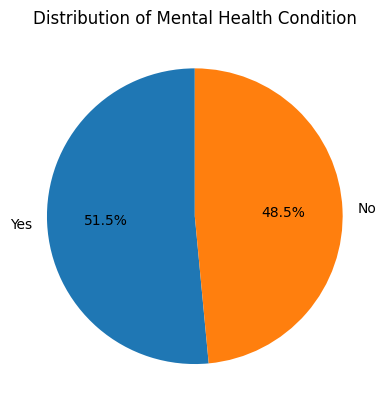

In [27]:
import matplotlib.pyplot as plt

counts = df["Mental_Health_Condition"].value_counts()

plt.figure()
counts.plot(kind="pie",autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Mental Health Condition")
plt.ylabel("")
plt.show() 

(0.0, 1.0)

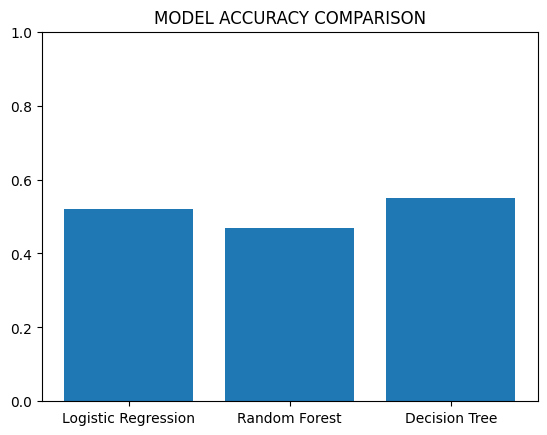

In [29]:
# This cell Visualize the Model Accuracy Comparison Chart
models = ["Logistic Regression", "Random Forest", "Decision Tree"]
scores = [0.52, 0.47, 0.55]

plt.figure()
plt.bar(models, scores)
plt.title("MODEL ACCURACY COMPARISON")
plt.ylim(0,1)


Text(50.722222222222214, 0.5, 'Actual')

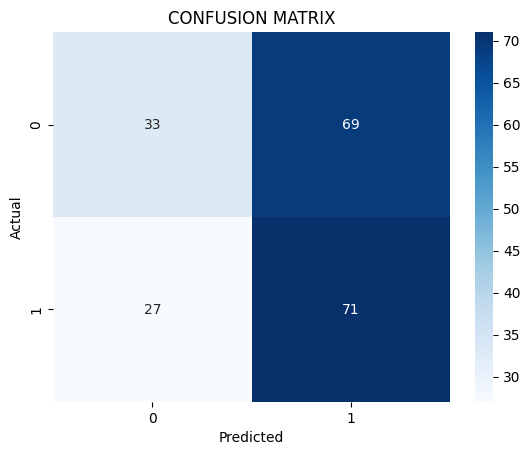

In [30]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CONFUSION MATRIX")
plt.xlabel("Predicted")
plt.ylabel("Actual")